### Market Value Analysis

The most interesting application of this project so far has been to identify players who are overperforming their expected attacking involvement comapred to their usage rate, i.e. the identification of efficient creators. We can define this with a new metric called, Relative Creative Efficiency (RCE), calculated by: 
$$ \text{RCE} = \frac{\text{Attacking Involvement}}{\text{Usage Rate}}$$

This is a direct quantification of how efficiently player's use their share of the ball within a team, and a general indicator of the stand-out attacking players. A value above 1 indicates efficient creators, while a value below 1 indicates players who use the ball inefficiently.]

Since we also have access to each player's current market value, we decided an extension of this project would be to investigate if there is any relationship between RCE and market value. While market value depends on a complexity of various factors like age and position, this could still prove a useful exercise with applications of scouting undervalued attacking players with excellent attacking efficiency. 

In [1]:
# 1. Load the data
import pandas as pd
from pathlib import Path

# Data folders
project_folder = Path.cwd().parent 
player_data = pd.read_csv(project_folder / "data" / "player_usage_data.csv")

In [3]:
# 2: Create a dictionary for team kit colours for plotting
kit_colours = {
    42 : "#EF0107",
    34 : "#FFFFFF",
    30 : "#005DAA",
    50 : "#E30613",
    41 : "#EB172B",
    60 : "#DA291C",
    40 : "#670e36",
    14 : "#DD0000",
    3 : "#FDB913",
    17 : "#6CADDF",
    43 : "#FFFFFF",
    37 : "#7C2C3B",
    33 : "#132257",
    7 : "#0055A5",
    35 : "#C1040B",
    38 : "#001489",
    6 : "#5F0041",
    48 : "#00009E",
    39 : "#231F20",
    44 : "#E51C25"}

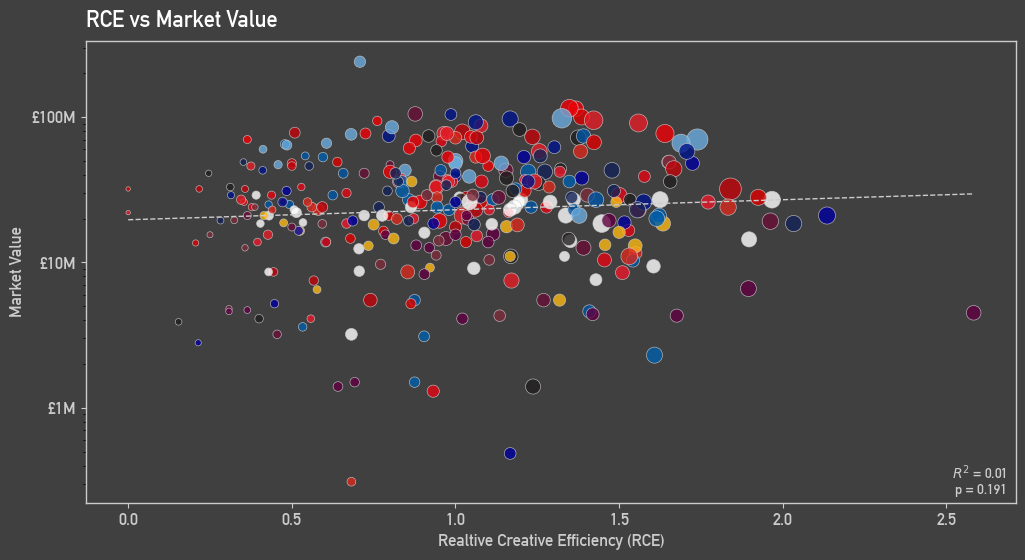

In [5]:
# 3: Plot RCE v Market Value for all players with sufficient minutes
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress
from matplotlib.ticker import FuncFormatter


# Remove players with less than 10 matches played
player_data = player_data[player_data["minutesPlayed"] >= 900]

# Define default font
plt.rcParams["font.family"] = "DIN Alternate"

# Use SCA / 90 for marker size
sizes = 10 + player_data["SCA/90"] * 40

# Define the team colours
point_colours = player_data["teamId"].map(kit_colours)

# Initialise the figure
fig,ax = plt.subplots(1,1, figsize = (12,6), facecolor = "#404040")

# Plot the data
ax.scatter(player_data["RCE"],
           player_data["marketValue"],
           s = sizes,
           c = point_colours,
           alpha = 0.8,
           edgecolor = "#CCCCCC",
           linewidth = 0.5)

# Figure customisation
ax.set_title(f"RCE vs Market Value",
                  fontsize = 16,
                  pad = 10,
                  color = "white",
                  loc = "left")
ax.set_xlabel("Realtive Creative Efficiency (RCE)",
                  fontsize = 12,
                  color = "#CCCCCC")
ax.set_ylabel("Market Value",
                  fontsize = 12,
                  color = "#CCCCCC")
ax.set_yscale("log")
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"£{x/1e6:.0f}M")
)
ax.set_facecolor("#404040")
ax.tick_params(axis = "both",
              labelsize = 12,
              labelcolor = "#CCCCCC",
              color = "#CCCCCC")
for spine in ax.spines.values():
    spine.set_color("#CCCCCC")
    spine.set_linewidth(1)

# Fit a linear regression
x = player_data["RCE"]
y = np.log(player_data["marketValue"])

slope, intercept, r_value, p_value, std_err = linregress(x, y)

x_line = np.linspace(x.min(), x.max(), 100)
y_line = np.exp(intercept + slope * x_line)

ax.plot(x_line,
        y_line,
        linestyle="--",
        color = "#CCCCCC",
        linewidth = 1)

# annotate r^2 and p values
r_squared = r_value **2
ax.text(
    0.99, 0.05,
    f"$R^2$ = {r_squared:.2f}\np = {p_value:.3f}",
    transform=ax.transAxes,
    fontsize = 10,
    color = "#CCCCCC",
    va = "center",
    ha = "right"
)

fig.savefig(project_folder / "figures/market-value/regression-1.png",
           format = "png",
           dpi = 150)


plt.show()

In [6]:
# 4: Investigate residual values and undervalued palyers
player_data["expected_log_value"] = (intercept + slope * player_data["RCE"])
player_data["log_value_residual"] = (np.log(player_data["marketValue"]) - player_data["expected_log_value"])
player_data["expected_market_value"] = np.exp(intercept + slope * player_data["RCE"])

columns = [
    "playerName",
    "teamName",
    "primaryPosition",
    "minutesPlayed",
    "RCE",
    "marketValue",
    "log_value_residual",
    "expected_market_value"
]
market_data = player_data[columns]

market_data.sort_values("log_value_residual", ascending = True)[columns].head(20)

,playerName,teamName,primaryPosition,minutesPlayed,RCE,marketValue,log_value_residual,expected_market_value
434,Adam Smith,Bournemouth,DR,1095,0.682,310000.0,-4.257077,2.188702e+07
178,Idrissa Gana Gueye,Everton,MC,2101,1.167,485000.0,-3.886499,2.363887e+07
186,Jordan Henderson,Brentford,MC,1929,0.932,1300000.0,-2.863220,2.277319e+07
259,Kieran Trippier,Newcastle United,DR,1592,1.237,1400000.0,-2.837533,2.390303e+07
348,Kyle Walker,Burnley,DR,3097,0.641,1400000.0,-2.742913,2.174502e+07
173,Joël Veltman,Brighton & Hove Albion,DR,1073,0.875,1500000.0,-2.711069,2.256803e+07
459,Josh Laurent,Burnley,MC,1783,0.692,1500000.0,-2.682016,2.192180e+07
41,Pascal Groß,Brighton & Hove Albion,MC,1636,1.608,2300000.0,-2.399996,2.535321e+07
279,Danny Welbeck,Brighton & Hove Albion,ST,2268,0.904,3100000.0,-1.989736,2.267218e+07
108,Michael Keane,Everton,DC,2619,0.214,2800000.0,-1.981975,2.031977e+07


### Limitations

Clearly the current model has some limitations that are not effectively allowing us to identify undervalued attacking players. The R^2 value is just 0.01 suggesting that very little of the variance in market value can be explained by RCE. The fact that there is a p-value of 0.191 shows this relationship is not statistically significant. This is likely because we are comparing all players across the league, regardless of age, position or contract expiary. 

These effects result in the most undervalued players all being relatively old, seasoned pros. For example, the single most undervalued palyer was Adam Smith, with an expected market value of £21,000,000 but the 35 year old has an actual market value of just £310,000. 

Therefore, to improve this model we will create a multivariable regression which accounts for player age and position to hopefully establish a better relationship. 


In [10]:
# 5. Multivariable regression
# Load the player details for date of birth
player_details = pd.read_csv(project_folder / "data/raw/player_details.csv")

# Merge player dobs
player_data = player_data.merge(player_details[["id","dob"]],
                               left_on = "playerId",
                               right_on = "id",
                               how = "left").copy()

# DONT RUN TWICE, WILL DUPLICATE COLS

In [82]:
# Check for any missing values
player_data["dob"].isna().sum()

# Convert to time stamps
player_data["dob"] = pd.to_datetime(player_data["dob"],utc=True).dt.tz_localize(None)

# Calculate age from dob
today = pd.Timestamp.today().normalize()

# Calculate age
player_data["age"] = (today - player_data["dob"]).dt.days / 365.25
player_data["age"] = player_data["age"].astype(int)

# Calculate age^2 for the regression
player_data["age_squared"] = player_data["age"]**2

In [84]:
import statsmodels.formula.api as smf
# Remove players with less than 10 games played
model_data = player_data[player_data["minutesPlayed"] >= 900].copy()

# Transform positionGroup from string to object
model_data["positionGroup"] = model_data["positionGroup"].astype(object)

model_data["age_c"] = model_data["age"] - model_data["age"].mean()
model_data["age_c_squared"] = model_data["age_c"] ** 2

# Train model
regression = smf.ols(
    "np.log(marketValue) ~ RCE + age + age_c_squared + C(positionGroup)",
    data=model_data
).fit()
print(regression.summary())

                             OLS Regression Results                            
Dep. Variable:     np.log(marketValue)   R-squared:                       0.531
Model:                             OLS   Adj. R-squared:                  0.520
Method:                  Least Squares   F-statistic:                     50.14
Date:                 Tue, 22 Sep 2026   Prob (F-statistic):           2.07e-47
Time:                         17:11:06   Log-Likelihood:                -306.49
No. Observations:                  318   AIC:                             629.0
Df Residuals:                      310   BIC:                             659.1
Df Model:                            7                                         
Covariance Type:             nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
In

In [88]:
model_data["predicted_log_value"] = regression.predict(model_data)

model_data["log_value_residual"] = (
    np.log(model_data["marketValue"])
    - model_data["predicted_log_value"]
)

columns = [
    "playerName",
    "teamName",
    "primaryPosition",
    "minutesPlayed",
    "RCE",
    "marketValue",
    "log_value_residual",
    "expected_market_value"
]
market_data = model_data[columns]

market_data.sort_values("log_value_residual", ascending = True)[columns].head(20)

,playerName,teamName,primaryPosition,minutesPlayed,RCE,marketValue,log_value_residual,expected_market_value
315,Josh Laurent,Burnley,MC,1783,0.692,1500000.0,-2.113555,2.192180e+07
310,Adam Smith,Bournemouth,DR,1095,0.682,310000.0,-1.827053,2.188702e+07
302,Lucas Pires,Burnley,DL,1406,1.676,4300000.0,-1.811624,2.562839e+07
308,Jacob Bruun Larsen,Burnley,LW,1038,1.419,4400000.0,-1.752893,2.460377e+07
240,Hjalmar Ekdal,Burnley,DC,1539,0.364,4700000.0,-1.728511,2.080947e+07
306,Axel Tuanzebe,Burnley,DC,1202,0.308,4600000.0,-1.583409,2.062529e+07
236,Marcus Edwards,Burnley,RW,1073,1.895,6600000.0,-1.491115,2.653512e+07
312,Lyle Foster,Burnley,ST,1372,0.905,8300000.0,-1.376813,2.267578e+07
90,Josh Cullen,Burnley,MC,1519,1.021,4099999.0,-1.376380,2.309725e+07
173,Freddie Potts,West Ham United,MC,1167,1.103,10400000.0,-1.356581,2.339990e+07
